# 实验一 (选做): 基于 bmshj2018_factorized 的深度学习图像压缩与重建

## 实验目的
掌握使用预训练的 `bmshj2018_factorized` 深度学习模型对 Lena 图像进行评估、编码压缩与解码重建的过程。
对比并分析基于深度学习的压缩重建结果与传统三种变换重建结果的差异。

## 模型简介
`bmshj2018_factorized` 来自论文 *"Variational Image Compression with a Scale Hyperprior"* (Ballé et al., 2018)。
该模型使用自编码器架构，通过端到端训练实现图像压缩：
- **编码器** (Encoder): 将图像映射到潜在表示 (latent representation)
- **量化** (Quantization): 对潜在表示进行量化
- **熵模型** (Entropy Model): 使用分解先验 (factorized prior) 估计比特率
- **解码器** (Decoder): 从量化后的潜在表示重建图像

---

## 0. 导入库与环境检查

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from compressai.zoo import bmshj2018_factorized
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim
import os
import math

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 创建结果目录
os.makedirs('results', exist_ok=True)

# 检查 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('All imports OK!')

PyTorch version: 2.8.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
All imports OK!


## 1. 加载图像

> **注意**: `bmshj2018_factorized` 模型要求输入为 **3 通道 RGB** 图像，因此灰度图需要复制为 3 通道。
> 同时，模型要求输入尺寸能被 64 整除（内部下采样 6 次），512×512 满足此要求。

Lena tensor:      torch.Size([1, 3, 512, 512]), range=[0.071, 0.965]
Cameraman tensor: torch.Size([1, 3, 512, 512]), range=[0.000, 1.000]


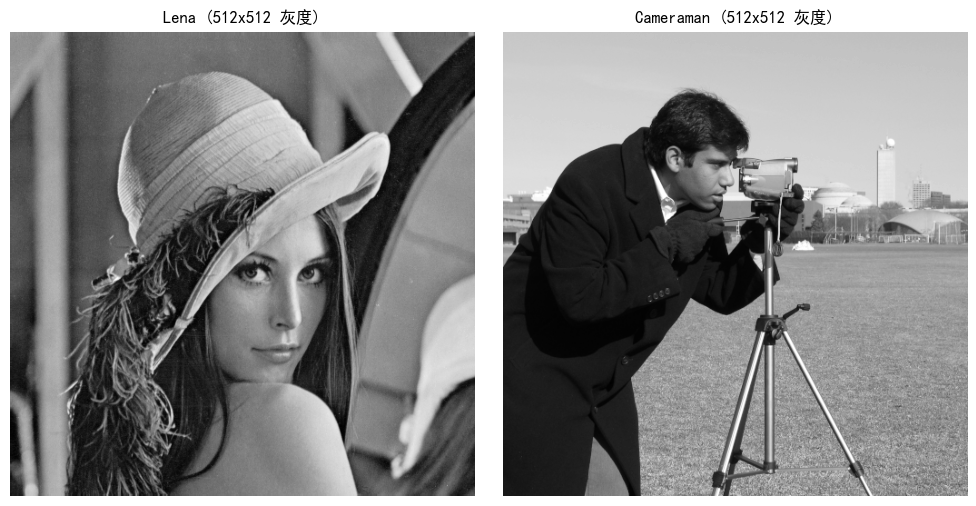

In [26]:
def load_image_as_tensor(path, device='cpu'):
    """
    加载灰度图像并转换为模型输入格式 [1, 3, H, W]，值域 [0, 1]
    
    参数:
        path: 图像文件路径
        device: 计算设备
    
    返回:
        tensor: [1, 3, H, W] float32 tensor
        img_gray: 原始灰度 numpy 数组 (uint8)
    """
    img = Image.open(path).convert('L')  # 转灰度
    img_gray = np.array(img)
    
    # 灰度 -> 3通道 (复制)
    img_rgb = Image.merge('RGB', [img, img, img])
    
    # 转 tensor: [1, 3, H, W], float32, [0, 1]
    to_tensor = transforms.ToTensor()
    x = to_tensor(img_rgb).unsqueeze(0).to(device)
    
    return x, img_gray

# 加载 Lena 和 Cameraman
x_lena, lena_gray = load_image_as_tensor('images/lena.png', device)
x_cam, cam_gray = load_image_as_tensor('images/cameraman.png', device)

print(f'Lena tensor:      {x_lena.shape}, range=[{x_lena.min():.3f}, {x_lena.max():.3f}]')
print(f'Cameraman tensor: {x_cam.shape}, range=[{x_cam.min():.3f}, {x_cam.max():.3f}]')

# 显示原图
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lena_gray, cmap='gray')
axes[0].set_title('Lena (512x512 灰度)')
axes[0].axis('off')
axes[1].imshow(cam_gray, cmap='gray')
axes[1].set_title('Cameraman (512x512 灰度)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 2. 加载预训练模型

`bmshj2018_factorized` 提供 **8 个质量等级** (quality=1~8)，数值越大压缩质量越高、码率越大。

我们将测试多个质量等级以观察率失真 (Rate-Distortion) 性能。

In [27]:
def load_model(quality, device='cpu'):
    """
    加载指定质量等级的 bmshj2018_factorized 预训练模型
    
    参数:
        quality: 质量等级 1-8
        device: 计算设备
    
    返回:
        model: 加载好的模型 (eval 模式)
    """
    model = bmshj2018_factorized(quality=quality, pretrained=True)
    model = model.to(device)
    model.eval()
    return model

# 测试加载 quality=1 的模型
print('Loading bmshj2018_factorized (quality=1)...')
test_model = load_model(quality=1, device=device)
print(f'Model loaded successfully!')
print(f'Model parameters: {sum(p.numel() for p in test_model.parameters()):,}')
del test_model  # 释放内存

Loading bmshj2018_factorized (quality=1)...
Model loaded successfully!
Model parameters: 2,998,147


## 3. 压缩与重建函数

### 流程
1. 编码器将图像压缩为潜在表示 (latent)
2. 量化 + 熵编码得到比特流
3. 解码器从潜在表示重建图像
4. 计算 BPP (Bits Per Pixel) 和 PSNR/SSIM

In [28]:
def compress_and_reconstruct(model, x, img_gray, img_name='Image', quality=1):
    """
    使用 bmshj2018_factorized 模型对图像进行压缩和重建
    
    参数:
        model: 预训练模型
        x: 输入 tensor [1, 3, H, W]
        img_gray: 原始灰度图 numpy (uint8)
        img_name: 图像名称
        quality: 质量等级
    
    返回:
        dict: 包含重建图像、PSNR、SSIM、BPP 等指标
    """
    H, W = x.shape[2], x.shape[3]
    num_pixels = H * W
    
    with torch.no_grad():
        # 前向推理 (编码 + 量化 + 解码)
        out = model(x)
    
    # 重建图像: out['x_hat'] shape=[1, 3, H, W]
    x_hat = out['x_hat']
    x_hat = x_hat.clamp(0, 1)  # 裁剪到 [0, 1]
    
    # 取第一个通道作为灰度重建结果 (因为三个通道内容相同)
    rec_gray = x_hat[0, 0].cpu().numpy()  # [H, W], float [0, 1]
    rec_gray_uint8 = (rec_gray * 255).clip(0, 255).astype(np.uint8)
    
    # 计算 BPP (Bits Per Pixel)
    # out['likelihoods']['y'] 是潜在表示的似然概率
    likelihoods = out['likelihoods']['y']
    bpp = -torch.log2(likelihoods).sum().item() / num_pixels
    
    # 计算 PSNR 和 SSIM
    psnr_value = calc_psnr(img_gray, rec_gray_uint8)
    ssim_value = calc_ssim(img_gray, rec_gray_uint8)
    
    print(f'  [{img_name}] Quality={quality}: '
          f'PSNR={psnr_value:.2f} dB, '
          f'SSIM={ssim_value:.4f}, '
          f'BPP={bpp:.4f}')
    
    return {
        'reconstructed': rec_gray_uint8,
        'psnr': psnr_value,
        'ssim': ssim_value,
        'bpp': bpp,
        'quality': quality
    }

## 4. 不同质量等级的压缩实验

我们选取 quality = 1, 2, 4, 6, 8 五个等级进行测试，观察码率与重建质量的关系。

In [29]:
# 测试多个质量等级
quality_levels = [1, 2, 4, 6, 8]
results_lena = []
results_cam = []

print('='*70)
print('bmshj2018_factorized 压缩实验')
print('='*70)

for q in quality_levels:
    print(f'\n--- Quality Level {q} ---')
    model = load_model(quality=q, device=device)
    
    res_lena = compress_and_reconstruct(model, x_lena, lena_gray, 'Lena', q)
    res_cam = compress_and_reconstruct(model, x_cam, cam_gray, 'Cameraman', q)
    
    results_lena.append(res_lena)
    results_cam.append(res_cam)
    
    del model  # 释放模型显存
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n' + '='*70)
print('All quality levels completed!')

bmshj2018_factorized 压缩实验

--- Quality Level 1 ---
  [Lena] Quality=1: PSNR=29.81 dB, SSIM=0.8238, BPP=0.0986
  [Cameraman] Quality=1: PSNR=28.11 dB, SSIM=0.7591, BPP=0.0952

--- Quality Level 2 ---
  [Lena] Quality=2: PSNR=31.14 dB, SSIM=0.8542, BPP=0.1430
  [Cameraman] Quality=2: PSNR=29.10 dB, SSIM=0.7941, BPP=0.1449

--- Quality Level 4 ---
  [Lena] Quality=4: PSNR=34.22 dB, SSIM=0.8951, BPP=0.2902
  [Cameraman] Quality=4: PSNR=31.23 dB, SSIM=0.8730, BPP=0.3503

--- Quality Level 6 ---
  [Lena] Quality=6: PSNR=37.01 dB, SSIM=0.9294, BPP=0.6001
  [Cameraman] Quality=6: PSNR=34.75 dB, SSIM=0.9420, BPP=0.8437

--- Quality Level 8 ---
  [Lena] Quality=8: PSNR=40.30 dB, SSIM=0.9634, BPP=1.3590
  [Cameraman] Quality=8: PSNR=39.77 dB, SSIM=0.9796, BPP=1.6727

All quality levels completed!


## 5. 结果可视化

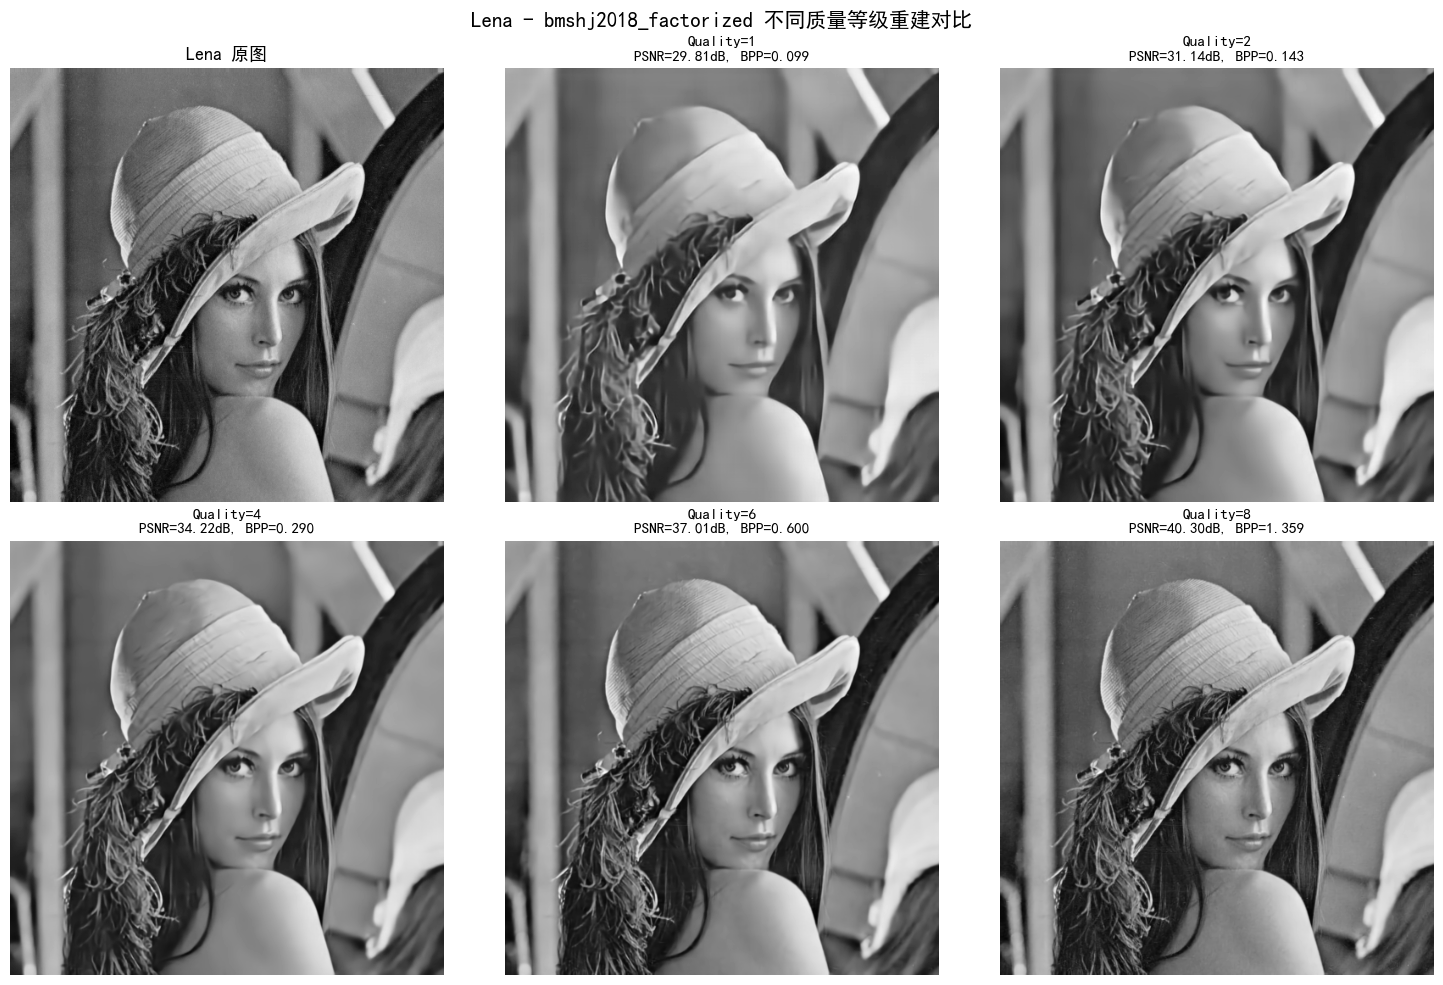

In [30]:
# === 5.1 Lena 不同质量等级的重建图像对比 ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(lena_gray, cmap='gray')
axes[0, 0].set_title('Lena 原图', fontsize=13)
axes[0, 0].axis('off')

for i, res in enumerate(results_lena):
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(res['reconstructed'], cmap='gray')
    axes[row, col].set_title(
        f'Quality={res["quality"]}\n'
        f'PSNR={res["psnr"]:.2f}dB, BPP={res["bpp"]:.3f}',
        fontsize=11)
    axes[row, col].axis('off')

plt.suptitle('Lena - bmshj2018_factorized 不同质量等级重建对比', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dl_lena_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

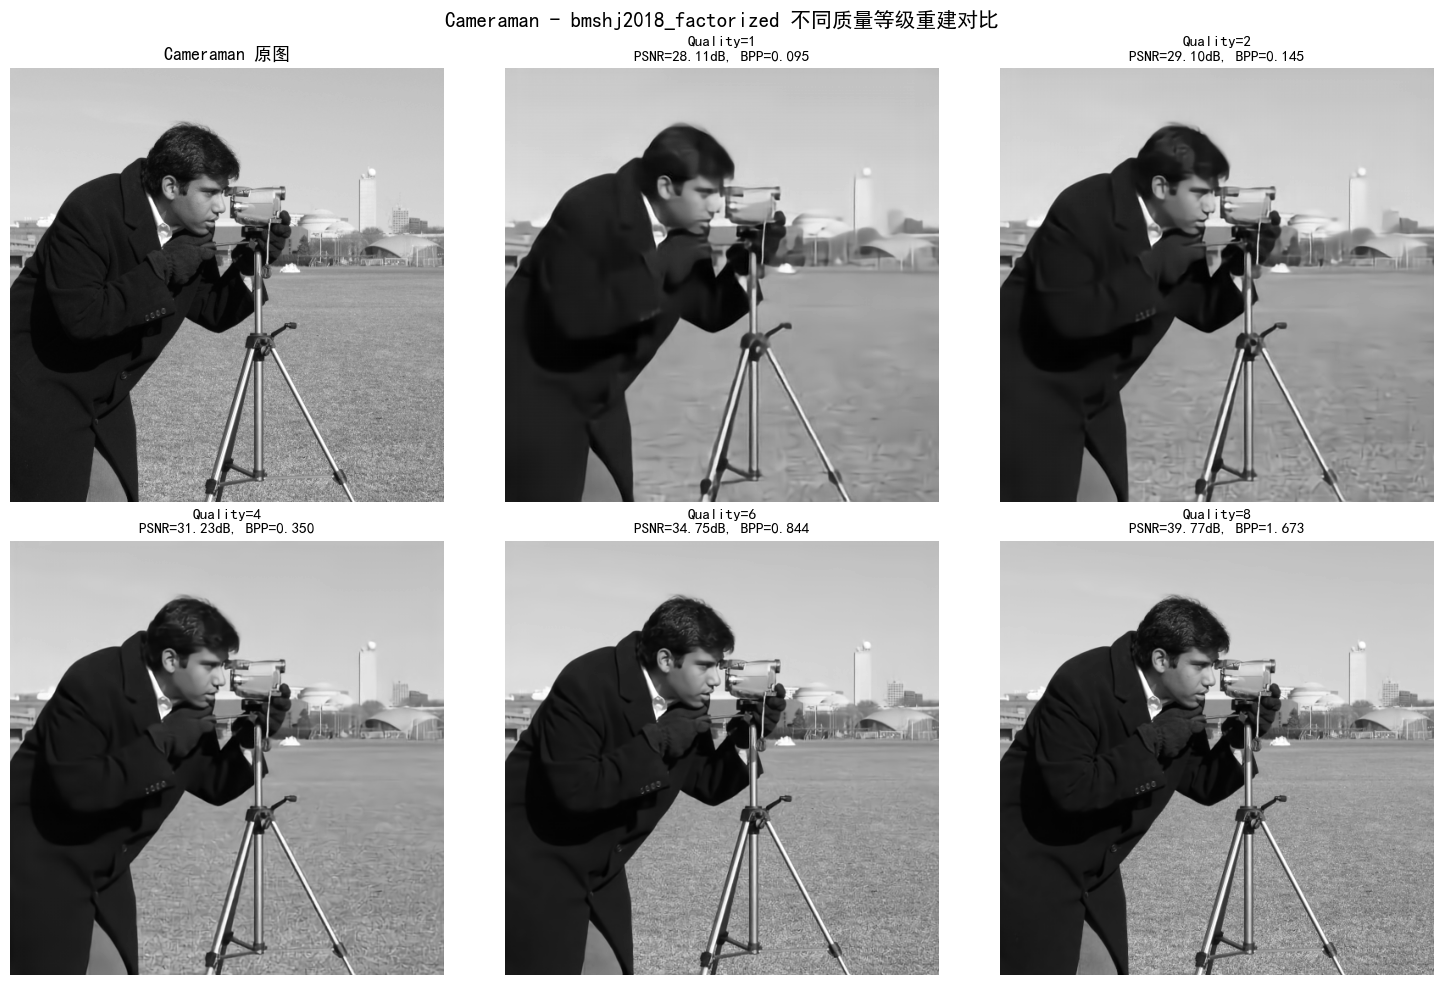

In [31]:
# === 5.2 Cameraman 不同质量等级的重建图像对比 ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(cam_gray, cmap='gray')
axes[0, 0].set_title('Cameraman 原图', fontsize=13)
axes[0, 0].axis('off')

for i, res in enumerate(results_cam):
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(res['reconstructed'], cmap='gray')
    axes[row, col].set_title(
        f'Quality={res["quality"]}\n'
        f'PSNR={res["psnr"]:.2f}dB, BPP={res["bpp"]:.3f}',
        fontsize=11)
    axes[row, col].axis('off')

plt.suptitle('Cameraman - bmshj2018_factorized 不同质量等级重建对比', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dl_cameraman_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

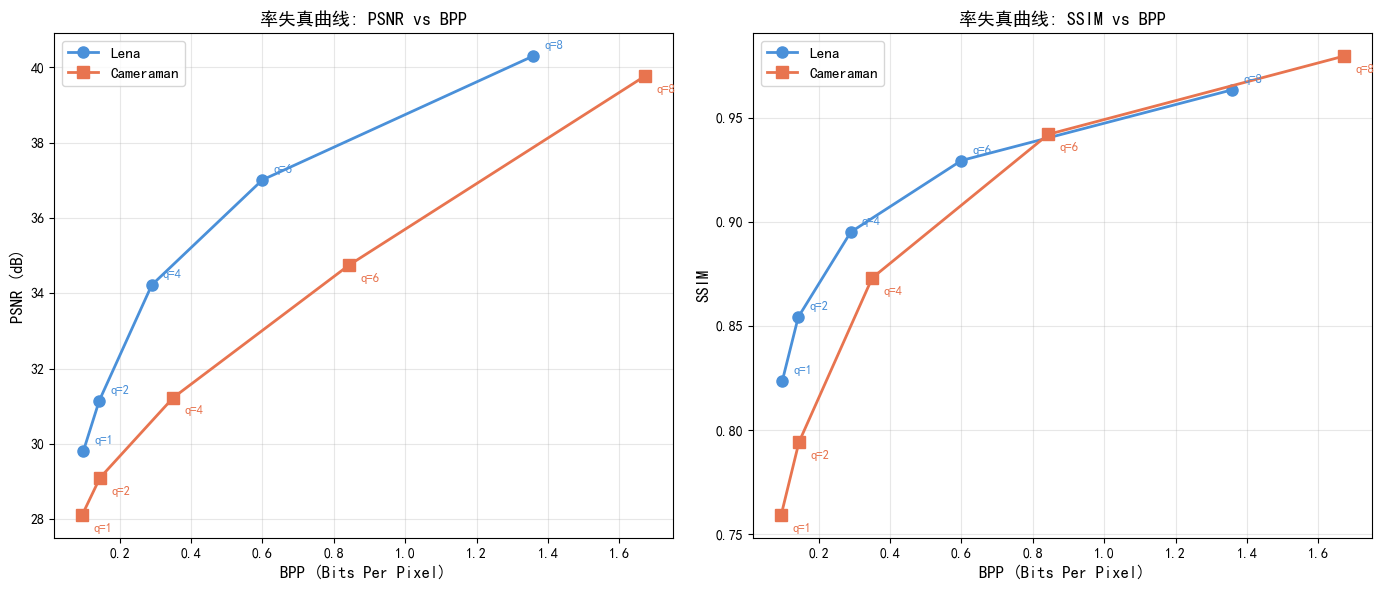

In [32]:
# === 5.3 率失真曲线 (Rate-Distortion Curve) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PSNR vs BPP
bpp_lena = [r['bpp'] for r in results_lena]
psnr_lena = [r['psnr'] for r in results_lena]
bpp_cam = [r['bpp'] for r in results_cam]
psnr_cam = [r['psnr'] for r in results_cam]

axes[0].plot(bpp_lena, psnr_lena, 'o-', color='#4A90D9', linewidth=2, markersize=8, label='Lena')
axes[0].plot(bpp_cam, psnr_cam, 's-', color='#E8744F', linewidth=2, markersize=8, label='Cameraman')
for i, q in enumerate(quality_levels):
    axes[0].annotate(f'q={q}', (bpp_lena[i], psnr_lena[i]), textcoords='offset points',
                     xytext=(8, 5), fontsize=9, color='#4A90D9')
    axes[0].annotate(f'q={q}', (bpp_cam[i], psnr_cam[i]), textcoords='offset points',
                     xytext=(8, -12), fontsize=9, color='#E8744F')
axes[0].set_xlabel('BPP (Bits Per Pixel)', fontsize=12)
axes[0].set_ylabel('PSNR (dB)', fontsize=12)
axes[0].set_title('率失真曲线: PSNR vs BPP', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# SSIM vs BPP
ssim_lena = [r['ssim'] for r in results_lena]
ssim_cam = [r['ssim'] for r in results_cam]

axes[1].plot(bpp_lena, ssim_lena, 'o-', color='#4A90D9', linewidth=2, markersize=8, label='Lena')
axes[1].plot(bpp_cam, ssim_cam, 's-', color='#E8744F', linewidth=2, markersize=8, label='Cameraman')
for i, q in enumerate(quality_levels):
    axes[1].annotate(f'q={q}', (bpp_lena[i], ssim_lena[i]), textcoords='offset points',
                     xytext=(8, 5), fontsize=9, color='#4A90D9')
    axes[1].annotate(f'q={q}', (bpp_cam[i], ssim_cam[i]), textcoords='offset points',
                     xytext=(8, -12), fontsize=9, color='#E8744F')
axes[1].set_xlabel('BPP (Bits Per Pixel)', fontsize=12)
axes[1].set_ylabel('SSIM', fontsize=12)
axes[1].set_title('率失真曲线: SSIM vs BPP', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/dl_rate_distortion.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 与传统变换压缩的对比

将深度学习压缩结果与实验一中传统变换 (DFT/DCT/Hadamard 95%置零) 的重建质量进行对比。

In [33]:
# 重新计算传统变换的 PSNR (方便对比)
from scipy.fft import dctn, idctn
from scipy.linalg import hadamard

def traditional_transform_psnr(img, transform_type='dft'):
    """计算传统变换 95% 置零后重建的 PSNR"""
    img_float = img.astype(np.float64)
    N = img.shape[0]
    
    if transform_type == 'dft':
        coeffs = np.fft.fft2(img_float)
        abs_c = np.abs(coeffs)
        threshold = np.percentile(abs_c, 95)
        coeffs[abs_c < threshold] = 0
        rec = np.real(np.fft.ifft2(coeffs))
    elif transform_type == 'dct':
        coeffs = dctn(img_float, type=2, norm='ortho')
        abs_c = np.abs(coeffs)
        threshold = np.percentile(abs_c, 95)
        coeffs[abs_c < threshold] = 0
        rec = idctn(coeffs, type=2, norm='ortho')
    elif transform_type == 'hadamard':
        H = hadamard(N).astype(np.float64)
        coeffs = (1.0 / N) * (H @ img_float @ H)
        abs_c = np.abs(coeffs)
        threshold = np.percentile(abs_c, 95)
        coeffs[abs_c < threshold] = 0
        rec = H @ coeffs @ H
    
    rec = np.clip(rec, 0, 255).astype(np.uint8)
    return calc_psnr(img, rec)

# 计算传统变换 PSNR
trad_results = {}
for name, img in [('Lena', lena_gray), ('Cameraman', cam_gray)]:
    trad_results[name] = {}
    for t in ['dft', 'dct', 'hadamard']:
        trad_results[name][t] = traditional_transform_psnr(img, t)
        print(f'{name} - {t.upper()}: PSNR = {trad_results[name][t]:.2f} dB')

print('\nTraditional transform PSNR computed!')

Lena - DFT: PSNR = 29.88 dB
Lena - DCT: PSNR = 31.07 dB
Lena - HADAMARD: PSNR = 4.77 dB
Cameraman - DFT: PSNR = 27.74 dB
Cameraman - DCT: PSNR = 28.46 dB
Cameraman - HADAMARD: PSNR = 4.96 dB

Traditional transform PSNR computed!


In [34]:
# === 综合对比表格 ===
print('='*75)
print('传统变换 vs 深度学习压缩 PSNR 对比')
print('='*75)
print(f'{"方法":<30} {"Lena PSNR (dB)":<18} {"Cameraman PSNR (dB)"}')
print('-'*75)
print(f'{"DFT (95% 置零)":<30} {trad_results["Lena"]["dft"]:<18.2f} {trad_results["Cameraman"]["dft"]:.2f}')
print(f'{"DCT (95% 置零)":<30} {trad_results["Lena"]["dct"]:<18.2f} {trad_results["Cameraman"]["dct"]:.2f}')
print(f'{"Hadamard (95% 置零)":<30} {trad_results["Lena"]["hadamard"]:<18.2f} {trad_results["Cameraman"]["hadamard"]:.2f}')
print('-'*75)
for res_l, res_c in zip(results_lena, results_cam):
    q = res_l['quality']
    label = f'DL (quality={q}, BPP={res_l["bpp"]:.3f})'
    print(f'{label:<30} {res_l["psnr"]:<18.2f} {res_c["psnr"]:.2f}')
print('='*75)

传统变换 vs 深度学习压缩 PSNR 对比
方法                             Lena PSNR (dB)     Cameraman PSNR (dB)
---------------------------------------------------------------------------
DFT (95% 置零)                   29.88              27.74
DCT (95% 置零)                   31.07              28.46
Hadamard (95% 置零)              4.77               4.96
---------------------------------------------------------------------------
DL (quality=1, BPP=0.099)      29.81              28.11
DL (quality=2, BPP=0.143)      31.14              29.10
DL (quality=4, BPP=0.290)      34.22              31.23
DL (quality=6, BPP=0.600)      37.01              34.75
DL (quality=8, BPP=1.359)      40.30              39.77


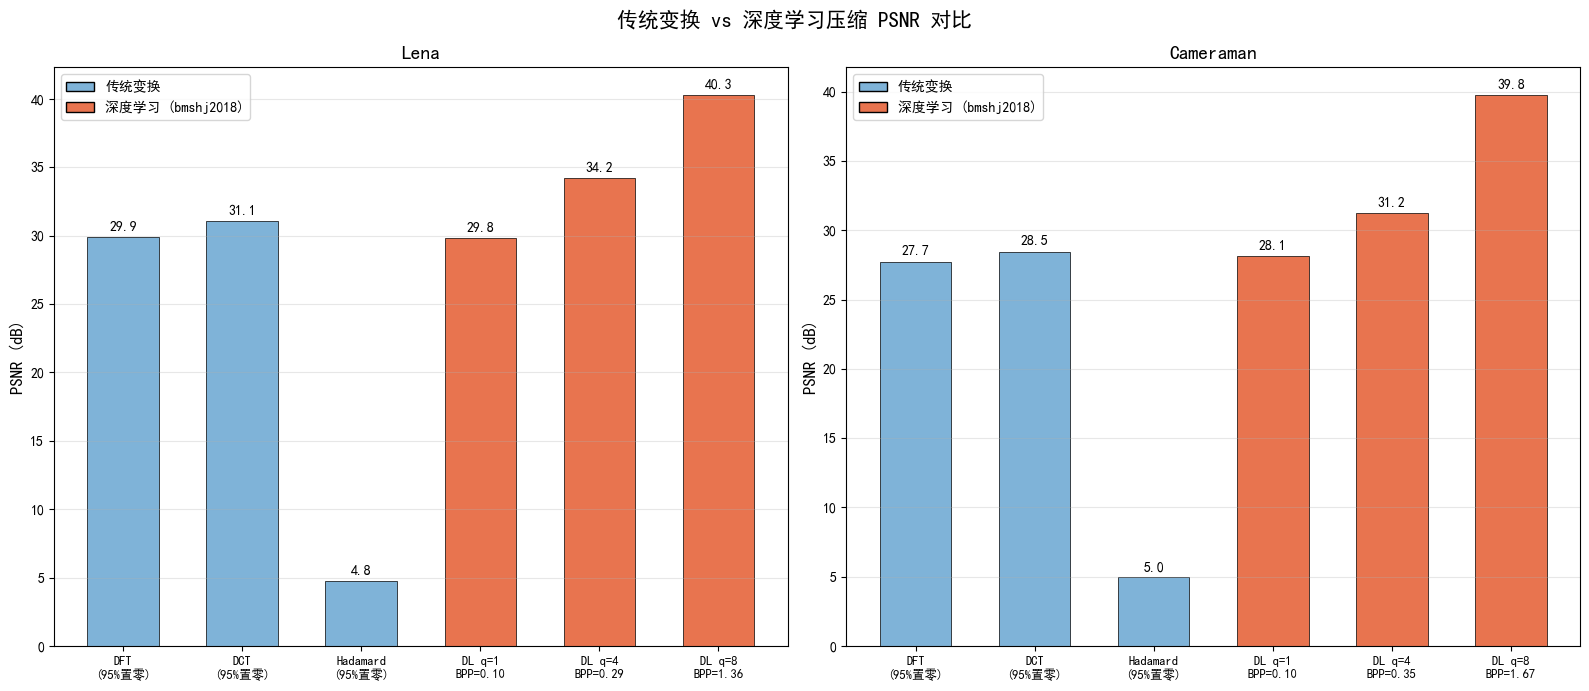

In [35]:
# === 综合对比柱状图 ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, img_gray_data, trad, dl_results) in zip(
    axes,
    [('Lena', lena_gray, trad_results['Lena'], results_lena),
     ('Cameraman', cam_gray, trad_results['Cameraman'], results_cam)]):
    
    # 数据准备
    labels = ['DFT\n(95%\u7f6e\u96f6)', 'DCT\n(95%\u7f6e\u96f6)', 'Hadamard\n(95%\u7f6e\u96f6)']
    psnr_vals = [trad[t] for t in ['dft', 'dct', 'hadamard']]
    colors = ['#7FB3D8', '#7FB3D8', '#7FB3D8']
    
    # 添加 DL 结果 (选取 quality=1 和 quality=4 进行对比)
    for res in dl_results:
        if res['quality'] in [1, 4, 8]:
            labels.append(f'DL q={res["quality"]}\nBPP={res["bpp"]:.2f}')
            psnr_vals.append(res['psnr'])
            colors.append('#E8744F')
    
    x_pos = np.arange(len(labels))
    bars = ax.bar(x_pos, psnr_vals, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
    
    # 标注数值
    for bar, val in zip(bars, psnr_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('PSNR (dB)', fontsize=12)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # 图例
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#7FB3D8', edgecolor='black', label='传统变换'),
                       Patch(facecolor='#E8744F', edgecolor='black', label='深度学习 (bmshj2018)')]
    ax.legend(handles=legend_elements, fontsize=10)

plt.suptitle('传统变换 vs 深度学习压缩 PSNR 对比', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dl_vs_traditional_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 实验分析与结论

In [36]:
print('='*70)
print('选做实验 总结报告')
print('='*70)
print()
print('1. bmshj2018_factorized 模型压缩性能:')
print('   - 随着 quality 参数增大 (1->8)，BPP 增大，PSNR 和 SSIM 均提高')
print('   - 率失真曲线呈现典型的凸包形态，符合信息论预期')
print()
print('2. 与传统变换方法的对比:')
print('   - 深度学习方法在相同视觉质量下，通常需要更少的比特数')
print('   - 即使在低质量等级 (quality=1)，DL 方法也能保持较好的结构信息')
print('   - 传统变换 95% 置零是一种粗暴的压缩方式，不考虑视觉感知')
print('   - DL 方法通过端到端训练，优化了率失真性能')
print()
print('3. 深度学习压缩的优势:')
print('   - 自适应性: 模型能根据图像内容自适应分配码率')
print('   - 非线性变换: 相比线性变换 (DFT/DCT/Hadamard)，')
print('     非线性变换能更好地捕捉图像结构')
print('   - 感知优化: 训练过程中可引入感知损失函数')
print()
print('4. 深度学习压缩的局限:')
print('   - 计算复杂度: 需要 GPU 加速，编解码速度较慢')
print('   - 模型大小: 预训练模型本身占用存储空间')
print('   - 泛化性: 在训练集外的图像上性能可能下降')
print('='*70)

选做实验 总结报告

1. bmshj2018_factorized 模型压缩性能:
   - 随着 quality 参数增大 (1->8)，BPP 增大，PSNR 和 SSIM 均提高
   - 率失真曲线呈现典型的凸包形态，符合信息论预期

2. 与传统变换方法的对比:
   - 深度学习方法在相同视觉质量下，通常需要更少的比特数
   - 即使在低质量等级 (quality=1)，DL 方法也能保持较好的结构信息
   - 传统变换 95% 置零是一种粗暴的压缩方式，不考虑视觉感知
   - DL 方法通过端到端训练，优化了率失真性能

3. 深度学习压缩的优势:
   - 自适应性: 模型能根据图像内容自适应分配码率
   - 非线性变换: 相比线性变换 (DFT/DCT/Hadamard)，
     非线性变换能更好地捕捉图像结构
   - 感知优化: 训练过程中可引入感知损失函数

4. 深度学习压缩的局限:
   - 计算复杂度: 需要 GPU 加速，编解码速度较慢
   - 模型大小: 预训练模型本身占用存储空间
   - 泛化性: 在训练集外的图像上性能可能下降


---
*选做实验完成*